# Union de archivos

In [ ]:
import pandas as pd

# Leer varios CSV
dataset1 = pd.read_csv('DATASET1.CSV')
dataset2 = pd.read_csv('DATASET2.CSV')
dataset3 = pd.read_csv('DATASET3.CSV')
dataset4 = pd.read_csv('DATASET4.CSV')
dataset5 = pd.read_csv('DATASET5.CSV')


# Concatenar los datasets
dataset_combinado = pd.concat([dataset1, dataset2, dataset3, dataset4, dataset5])

# Guardar el dataset combinado
dataset_combinado.to_csv('DATASETF.csv', index=False)


# Lectura Dataset

In [ ]:
import pandas as pd
df = pd.read_csv('DATASETF.csv')

# Conversion de datos

In [ ]:
#Conversion
df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True, errors='coerce')
df['Humidity']=pd.to_numeric(df['Humidity'], errors='coerce')
df['Temperature']=pd.to_numeric(df['Temperature'], errors='coerce')

In [ ]:
Hm=df['Humidity'].isnull().sum()
Dt=df['DATE'].isnull().sum()
Tm=df['Temperature'].isnull().sum()
print("Valores Faltantes Humedad: ",Hm)
print("Valores Faltantes Fecha: ",Dt)
print("Valores Faltantes Temperatura: ",Tm)

Valores Faltantes Humedad:  0
Valores Faltantes Fecha:  3
Valores Faltantes Temperatura:  0


In [ ]:
df['DATE']=df['DATE'].interpolate(method='linear')
df['DATE'] = df['DATE'].dt.round('S')

In [ ]:
df=df.drop(columns='Index')

In [ ]:
df.set_index('DATE', inplace=True)

# Downsampling

In [ ]:
# Resample a datos cada 30 minutos
df= df.resample('30T').mean()

# Visualizacion

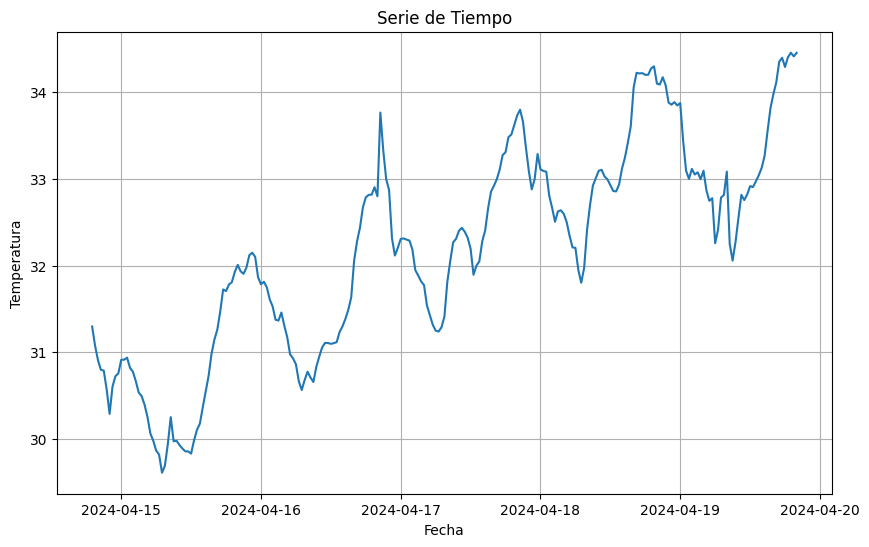

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Visualización Temperatura
plt.figure(figsize=(10, 6))
sns.lineplot(x=df.index, y='Temperature', data=df)
plt.title('Serie de Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Temperatura')
plt.grid(True)
plt.show()


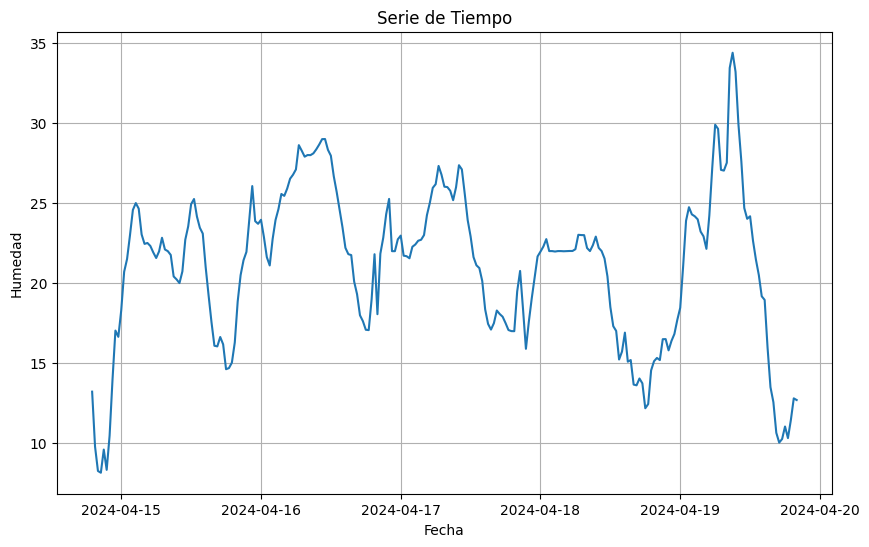

In [ ]:
# Visualización Humedad
plt.figure(figsize=(10, 6))
sns.lineplot(x=df.index, y='Humidity', data=df)
plt.title('Serie de Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Humedad')
plt.grid(True)
plt.show()


# Descomposicion

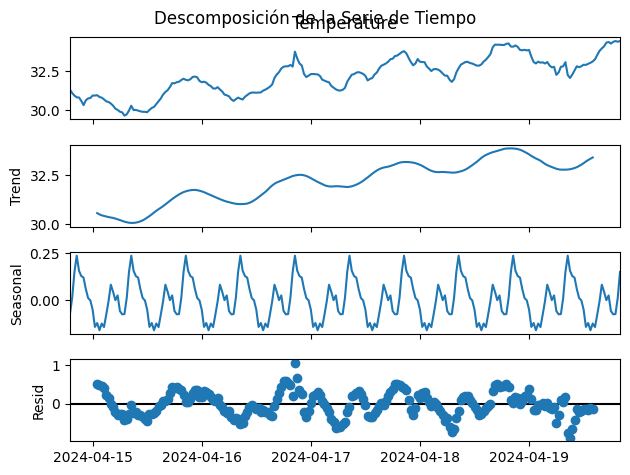

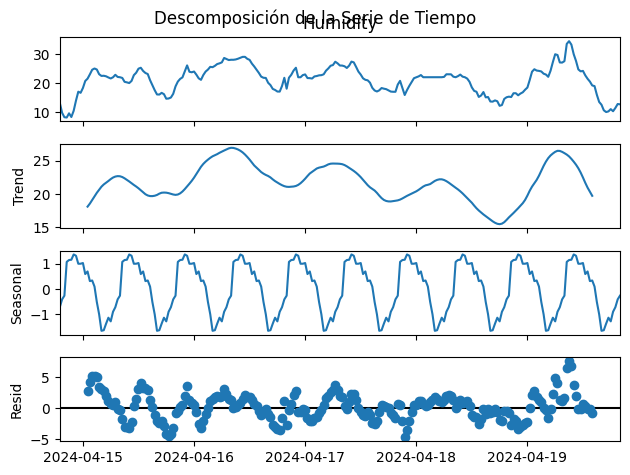

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición aditiva
result = seasonal_decompose(df['Temperature'], model='additive', period=24)

# Graficar los componentes
result.plot()
plt.suptitle('Descomposición de la Serie de Tiempo')
plt.show()

# Descomposición aditiva
result = seasonal_decompose(df['Humidity'], model='additive', period=24)

# Graficar los componentes
result.plot()
plt.suptitle('Descomposición de la Serie de Tiempo')
plt.show()


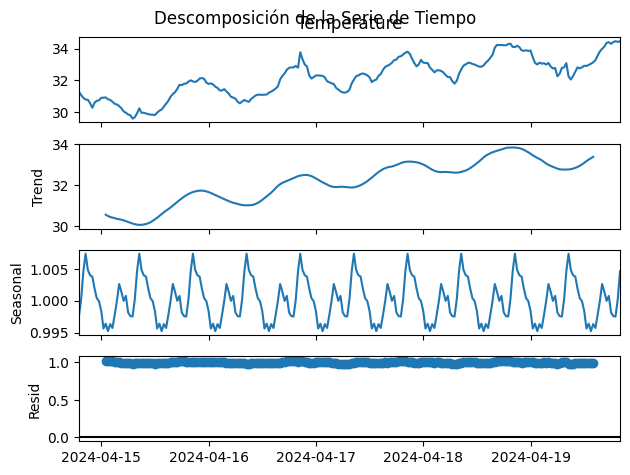

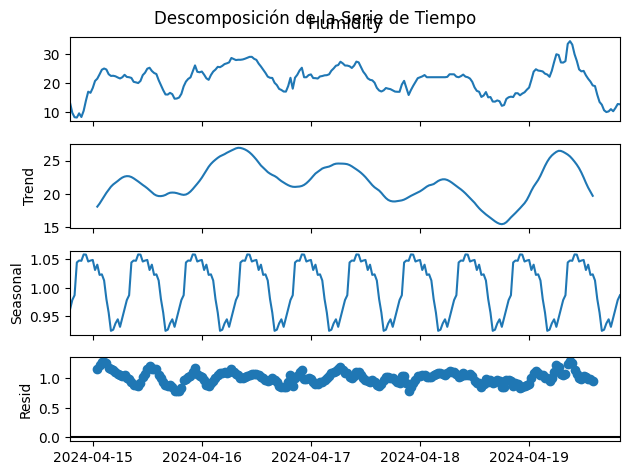

In [ ]:
# Descomposición multiplicativa
result = seasonal_decompose(df['Temperature'], model='multiplicative', period=24)

# Graficar los componentes
result.plot()
plt.suptitle('Descomposición de la Serie de Tiempo')
plt.show()

# Descomposición multiplicativa
result = seasonal_decompose(df['Humidity'], model='multiplicative', period=24)

# Graficar los componentes
result.plot()
plt.suptitle('Descomposición de la Serie de Tiempo')
plt.show()


# Modelo ingenuo

Error Absoluto Medio (MAE): 0.133764192897146
Error Cuadrático Medio (RMSE): 0.18293919598784428


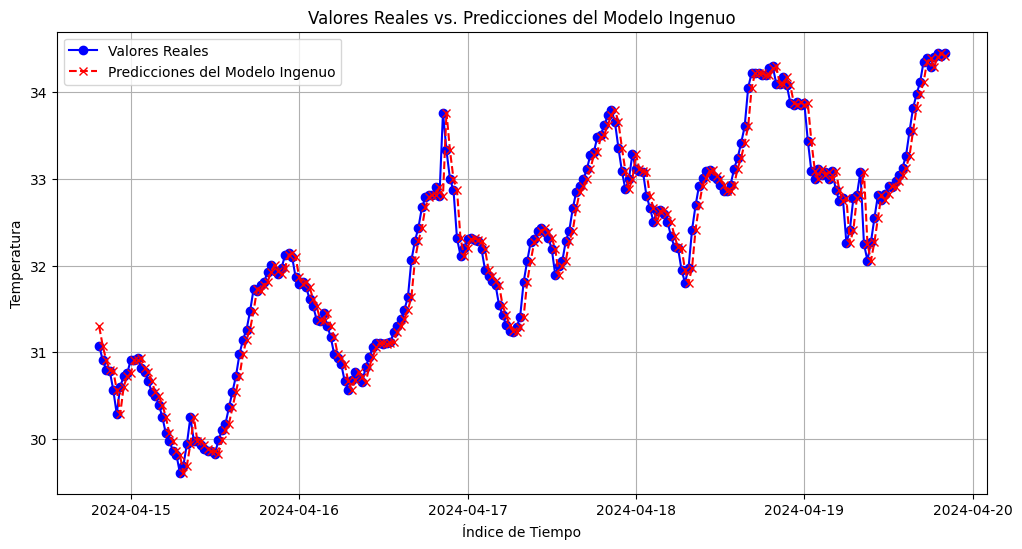

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Inicializar listas para almacenar los valores reales y las predicciones
real_values = []
predictions = []

# Recorrer cada punto de la serie de tiempo, uno por uno
for i in range(1, len(df)):
    # El modelo ingenuo predice que el próximo valor es el valor actual
    y_pred = df['Temperature'].iloc[i-1]
    y_true = df['Temperature'].iloc[i]

    # Guardar el valor real y la predicción
    predictions.append(y_pred)
    real_values.append(y_true)

# Convertir las listas a arrays para facilitar el cálculo de métricas
real_values = np.array(real_values)
predictions = np.array(predictions)

# Calcular el Error Absoluto Medio (MAE)
mae = mean_absolute_error(real_values, predictions)
print(f'Error Absoluto Medio (MAE): {mae}')

# Calcular el Error Cuadrático Medio (MSE) y la raíz (RMSE)
mse = mean_squared_error(real_values, predictions)
rmse = np.sqrt(mse)
print(f'Error Cuadrático Medio (RMSE): {rmse}')

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index[1:], real_values, label='Valores Reales', color='blue', linestyle='-', marker='o')
plt.plot(df.index[1:], predictions, label='Predicciones del Modelo Ingenuo', color='red', linestyle='--', marker='x')
plt.xlabel('Índice de Tiempo')
plt.ylabel('Temperatura')
plt.title('Valores Reales vs. Predicciones del Modelo Ingenuo')
plt.legend()
plt.grid(True)
plt.show()


Error Absoluto Medio (MAE): 0.9534892157948367
Error Cuadrático Medio (RMSE): 1.3137997745661016


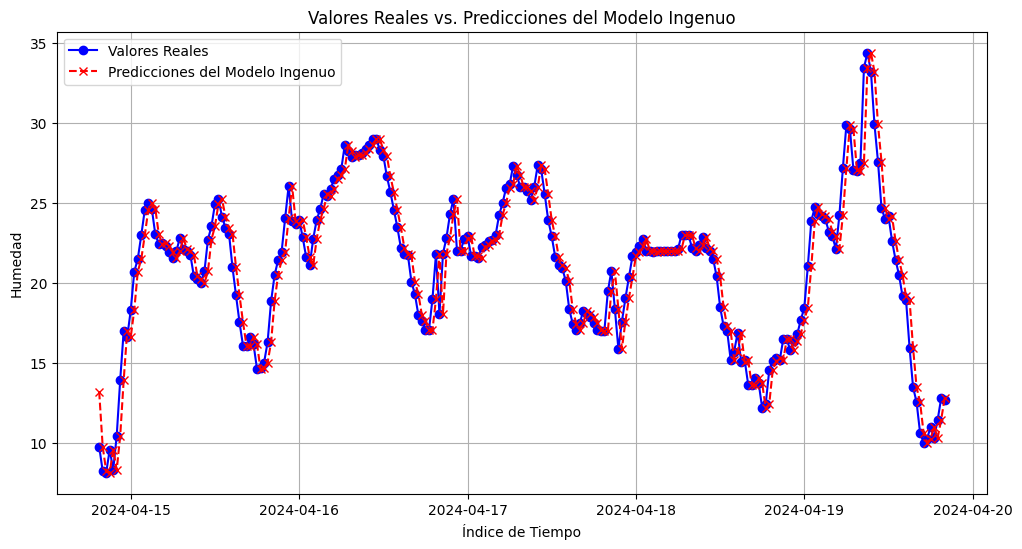

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Inicializar listas para almacenar los valores reales y las predicciones
real_values = []
predictions = []

# Recorrer cada punto de la serie de tiempo, uno por uno
for i in range(1, len(df)):
    # El modelo ingenuo predice que el próximo valor es el valor actual
    y_pred = df['Humidity'].iloc[i-1]
    y_true = df['Humidity'].iloc[i]

    # Guardar el valor real y la predicción
    predictions.append(y_pred)
    real_values.append(y_true)

# Convertir las listas a arrays para facilitar el cálculo de métricas
real_values = np.array(real_values)
predictions = np.array(predictions)

# Calcular el Error Absoluto Medio (MAE)
mae = mean_absolute_error(real_values, predictions)
print(f'Error Absoluto Medio (MAE): {mae}')

# Calcular el Error Cuadrático Medio (MSE) y la raíz (RMSE)
mse = mean_squared_error(real_values, predictions)
rmse = np.sqrt(mse)
print(f'Error Cuadrático Medio (RMSE): {rmse}')

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index[1:], real_values, label='Valores Reales', color='blue', linestyle='-', marker='o')
plt.plot(df.index[1:], predictions, label='Predicciones del Modelo Ingenuo', color='red', linestyle='--', marker='x')
plt.xlabel('Índice de Tiempo')
plt.ylabel('Humedad')
plt.title('Valores Reales vs. Predicciones del Modelo Ingenuo')
plt.legend()
plt.grid(True)
plt.show()


# pmdarima

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 48.1 MB/s eta 0:00:00


# ARIMA

<Figure size 1000x600 with 0 Axes>

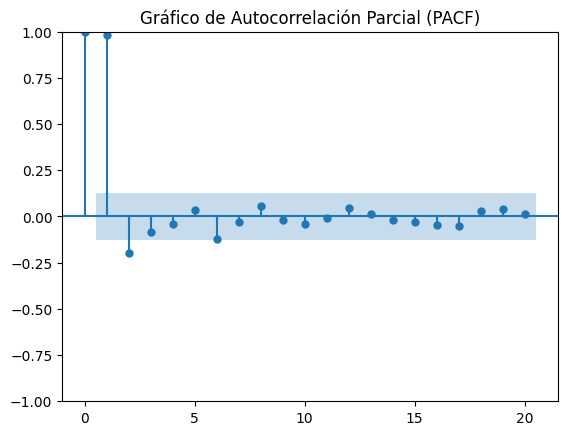

<Figure size 1000x600 with 0 Axes>

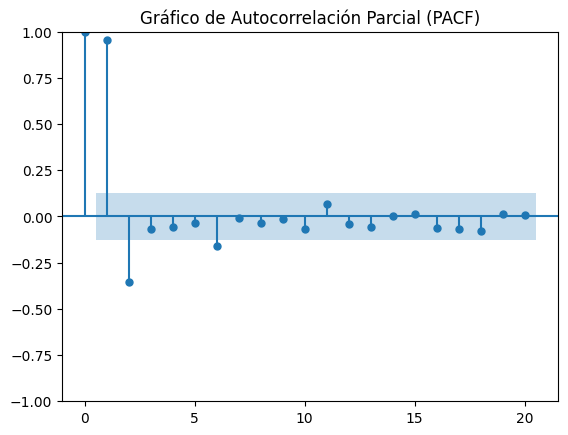

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Crear una serie de tiempo a partir de los datos
serie_temporal = pd.Series(df['Temperature'])

# Gráfico de autocorrelación
plt.figure(figsize=(10, 6))
plot_pacf(serie_temporal, lags=20, method='ywm')
plt.title('Gráfico de Autocorrelación Parcial (PACF)')
plt.show()
# Graficar la autocorrelación parcial (PACF)
serie_temporal1= pd.Series(df['Humidity'])
plt.figure(figsize=(10, 6))
plot_pacf(serie_temporal1, lags=20, method='ywm')
plt.title('Gráfico de Autocorrelación Parcial (PACF)')
plt.show()


<Figure size 1000x600 with 0 Axes>

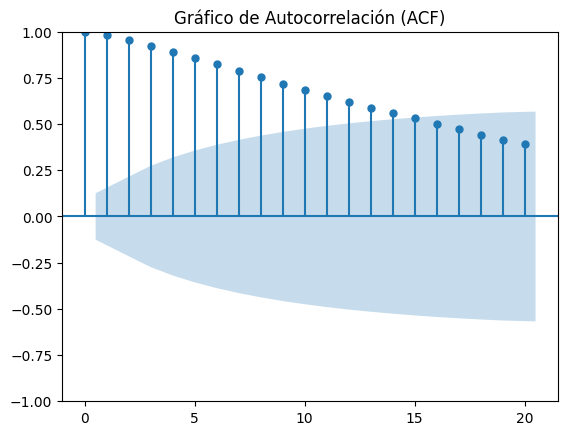

<Figure size 1000x600 with 0 Axes>

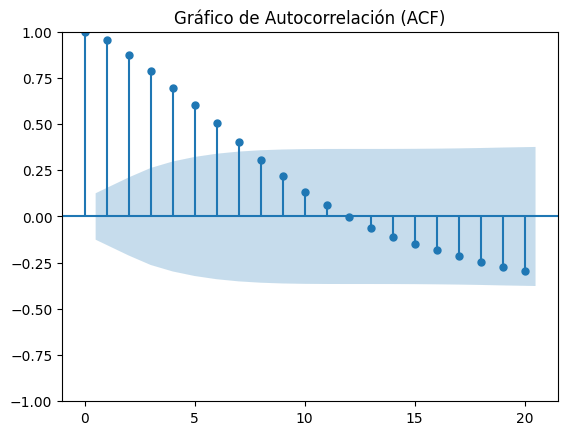

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Crear una serie de tiempo a partir de los datos
serie_temporal = pd.Series(df['Temperature'])

# Graficar la autocorrelación (ACF)
plt.figure(figsize=(10, 6))
plot_acf(serie_temporal, lags=20)
plt.title('Gráfico de Autocorrelación (ACF)')
plt.show()

# Crear una serie de tiempo a partir de los datos
serie_temporal = pd.Series(df['Humidity'])

# Graficar la autocorrelación (ACF)
plt.figure(figsize=(10, 6))
plot_acf(serie_temporal, lags=20)
plt.title('Gráfico de Autocorrelación (ACF)')
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller
series = df['Temperature']
# Prueba ADF para verificar la estacionariedad
result = adfuller(series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -1.7167419976134757
p-value: 0.4225077935159199


In [ ]:
from pmdarima import auto_arima

# Suponiendo que 'series' es tu serie temporal
model = auto_arima(series, seasonal=24, stepwise=True, trace=True)

# Obtener los mejores parámetros
print(model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-150.666, Time=0.61 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-132.591, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-154.032, Time=0.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-150.950, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-133.357, Time=0.03 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-152.725, Time=0.15 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-152.858, Time=0.26 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-150.985, Time=0.35 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-155.412, Time=0.04 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-154.182, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-154.344, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-152.144, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-152.551, Time=0.18 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 2.253 seconds
                      

Frecuencia de la serie temporal: <30 * Minutes>


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30T will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30T will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30T will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30T will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30T will be used.
  self._init

Error Cuadrático Medio (MSE): 0.03141323963901417
Raíz del Error Cuadrático Medio (RMSE): 0.177237805332311


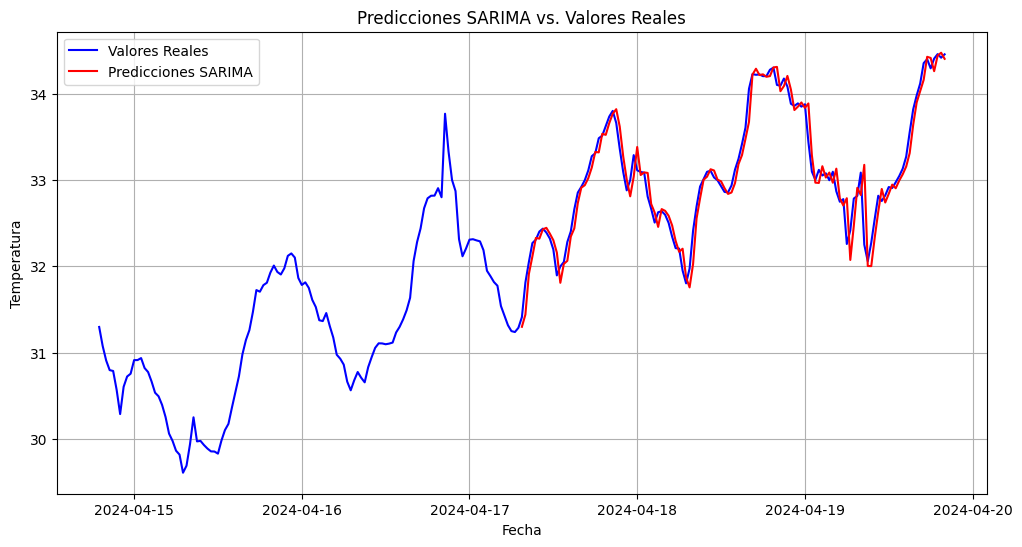

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def walk_forward_validation(series, order, seasonal_order, train_size):
    history = series[:train_size]
    predictions = []
    dates = series.index[train_size:]  # Índices de fechas para el conjunto de prueba

    for i in range(train_size, len(series)):
        model = SARIMAX(history, order=order, seasonal_order=seasonal_order, freq='30T')
        model_fit = model.fit(disp=False)
        # Obtener la predicción para el siguiente paso
        forecast = model_fit.forecast(steps=1)
        yhat = forecast.iloc[0]  # Extraer el valor predicho
        predictions.append(yhat)

        # Actualizar el conjunto de entrenamiento con el nuevo valor
        history = pd.concat([history, pd.Series(series.iloc[i], index=[series.index[i]])])

    # Asegurarse de que el índice de predicciones coincida con el índice de fechas de prueba
    predictions_series = pd.Series(predictions, index=dates)

    return predictions_series

# Cargar tus datos
series = df['Temperature']

# Convertir el índice a datetime y establecer la frecuencia
series.index = pd.to_datetime(series.index)

# Imprimir la frecuencia para verificar
print(f'Frecuencia de la serie temporal: {series.index.freq}')

# Parámetros del modelo SARIMA
order = (1, 1, 0)  # (p, d, q)
seasonal_order = (0, 0, 0, 24)  # (P, D, Q, m) - Ajustar según la estacionalidad de tus datos

# Tamaño de la ventana de entrenamiento
train_size = int(len(series) * 0.5)  # 50% de los datos para entrenamiento

# Ejecutar validación walk-forward
predictions_series = walk_forward_validation(series, order, seasonal_order, train_size)

# Calcular el error
test_values = series[train_size:]
mse = mean_squared_error(test_values, predictions_series)
rmse = np.sqrt(mse)
print(f'Error Cuadrático Medio (MSE): {mse}')
print(f'Raíz del Error Cuadrático Medio (RMSE): {rmse}')

# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(series.index, series, label='Valores Reales', color='blue')
plt.plot(predictions_series.index, predictions_series, label='Predicciones SARIMA', color='red')
plt.xlabel('Fecha')
plt.ylabel('Temperatura')
plt.title('Predicciones SARIMA vs. Valores Reales')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller
series = df['Humidity']
# Prueba ADF para verificar la estacionariedad
result = adfuller(series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -3.4695047041268956
p-value: 0.008805700249855669


In [ ]:
from pmdarima import auto_arima

# Suponiendo que 'series' es tu serie temporal
model = auto_arima(series, seasonal=24, stepwise=True, trace=True)

# Obtener los mejores parámetros
print(model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=784.728, Time=2.26 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1467.372, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=827.595, Time=0.12 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1189.521, Time=0.44 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2185.279, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=792.494, Time=1.48 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=790.877, Time=0.21 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=793.420, Time=0.69 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=795.058, Time=0.51 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=794.370, Time=0.11 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=793.585, Time=0.24 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=792.375, Time=0.62 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.87 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=801.546, Time=0.10 sec

Best model:  ARIMA(2,0,2)(0,0,0)[0] intercept
T

Frecuencia de la serie temporal: <30 * Minutes>


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30T will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30T will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30T will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so infer

Error Cuadrático Medio (MSE): 1.49433305584913
Raíz del Error Cuadrático Medio (RMSE): 1.2224291618941074


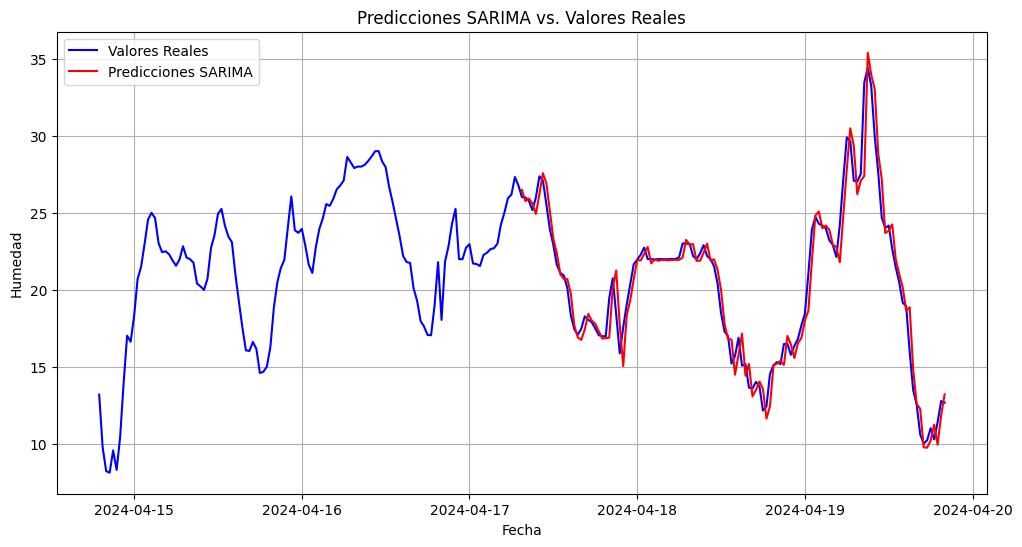

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def walk_forward_validation(series, order, seasonal_order, train_size):
    history = series[:train_size]
    predictions = []
    dates = series.index[train_size:]  # Índices de fechas para el conjunto de prueba

    for i in range(train_size, len(series)):
        model = SARIMAX(history, order=order, seasonal_order=seasonal_order, freq='30T')
        model_fit = model.fit(disp=False)
        # Obtener la predicción para el siguiente paso
        forecast = model_fit.forecast(steps=1)
        yhat = forecast.iloc[0]  # Extraer el valor predicho
        predictions.append(yhat)

        # Actualizar el conjunto de entrenamiento con el nuevo valor
        history = pd.concat([history, pd.Series(series.iloc[i], index=[series.index[i]])])

    # Asegurarse de que el índice de predicciones coincida con el índice de fechas de prueba
    predictions_series = pd.Series(predictions, index=dates)

    return predictions_series

# Cargar tus datos
series = df['Humidity']

# Convertir el índice a datetime y establecer la frecuencia
series.index = pd.to_datetime(series.index)

# Imprimir la frecuencia para verificar
print(f'Frecuencia de la serie temporal: {series.index.freq}')

# Parámetros del modelo SARIMA
order = (2, 0, 2)  # (p, d, q)
seasonal_order = (0, 0, 0, 24)  # (P, D, Q, m) - Ajustar según la estacionalidad de tus datos

# Tamaño de la ventana de entrenamiento
train_size = int(len(series) * 0.5)  # 50% de los datos para entrenamiento

# Ejecutar validación walk-forward
predictions_series = walk_forward_validation(series, order, seasonal_order, train_size)

# Calcular el error
test_values = series[train_size:]
mse = mean_squared_error(test_values, predictions_series)
rmse = np.sqrt(mse)
print(f'Error Cuadrático Medio (MSE): {mse}')
print(f'Raíz del Error Cuadrático Medio (RMSE): {rmse}')

# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(series.index, series, label='Valores Reales', color='blue')
plt.plot(predictions_series.index, predictions_series, label='Predicciones SARIMA', color='red')
plt.xlabel('Fecha')
plt.ylabel('Humedad')
plt.title('Predicciones SARIMA vs. Valores Reales')
plt.legend()
plt.grid(True)
plt.show()


# keras

In [ ]:
!pip install keras

# Redes Neuronales Feedforward

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn.metrics import mean_squared_error

# Definir el tamaño de la ventana
window_size = 5

# Crear las ventanas deslizantes para el conjunto de datos
def create_dataset(df, window_size):
    X, y = [], []
    values = df['Temperature'].values
    for i in range(len(values) - window_size):
        X.append(values[i:i + window_size])
        y.append(values[i + window_size])
    return np.array(X), np.array(y)

# Preparar las entradas (X) y las salidas (y)
X, y = create_dataset(df, window_size)

# Definir el tamaño del conjunto de entrenamiento
train_size = int(len(X) * 0.5)

# Crear y compilar el modelo
def create_model(window_size):
    model = Sequential()
    model.add(Input(shape=(window_size,)))  # Definir la forma de entrada
    model.add(Dense(20, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# Validación Walk-Forward
predictions = []
model = create_model(window_size)

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# Entrenar el modelo con el conjunto inicial
model.fit(X_train, y_train, epochs=50, batch_size=1, verbose=2)

# Walk-forward
for i in range(len(X_test)):
    # Predecir el siguiente valor
    prediction = model.predict(X_test[i].reshape(1, -1), verbose=0)
    predictions.append(prediction[0, 0])

    # Agregar el nuevo punto a los datos de entrenamiento (ventana)
    X_train = np.vstack([X_train, X_test[i]])
    y_train = np.append(y_train, y_test[i])

    # Reentrenar el modelo con la nueva ventana
    model.fit(X_train, y_train, epochs=1, batch_size=1, verbose=0)

# Evaluar las predicciones
mse = mean_squared_error(y_test, predictions)
rsme = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rsme)

Epoch 1/50
119/119 - 1s - 7ms/step - loss: 0.5590
Epoch 2/50
119/119 - 0s - 1ms/step - loss: 0.1434
Epoch 3/50
119/119 - 0s - 1ms/step - loss: 0.1308
Epoch 4/50
119/119 - 0s - 1ms/step - loss: 0.2077
Epoch 5/50
119/119 - 0s - 1ms/step - loss: 0.1511
Epoch 6/50
119/119 - 0s - 2ms/step - loss: 0.1508
Epoch 7/50
119/119 - 0s - 3ms/step - loss: 0.2850
Epoch 8/50
119/119 - 0s - 1ms/step - loss: 0.1818
Epoch 9/50
119/119 - 0s - 1ms/step - loss: 0.1642
Epoch 10/50
119/119 - 0s - 1ms/step - loss: 0.1553
Epoch 11/50
119/119 - 0s - 2ms/step - loss: 0.1820
Epoch 12/50
119/119 - 0s - 3ms/step - loss: 0.1803
Epoch 13/50
119/119 - 0s - 1ms/step - loss: 0.1557
Epoch 14/50
119/119 - 0s - 1ms/step - loss: 0.1444
Epoch 15/50
119/119 - 0s - 1ms/step - loss: 0.2260
Epoch 16/50
119/119 - 0s - 2ms/step - loss: 0.1391
Epoch 17/50
119/119 - 0s - 2ms/step - loss: 0.2025
Epoch 18/50
119/119 - 0s - 1ms/step - loss: 0.1334
Epoch 19/50
119/119 - 0s - 1ms/step - loss: 0.1620
Epoch 20/50
119/119 - 0s - 2ms/step - lo

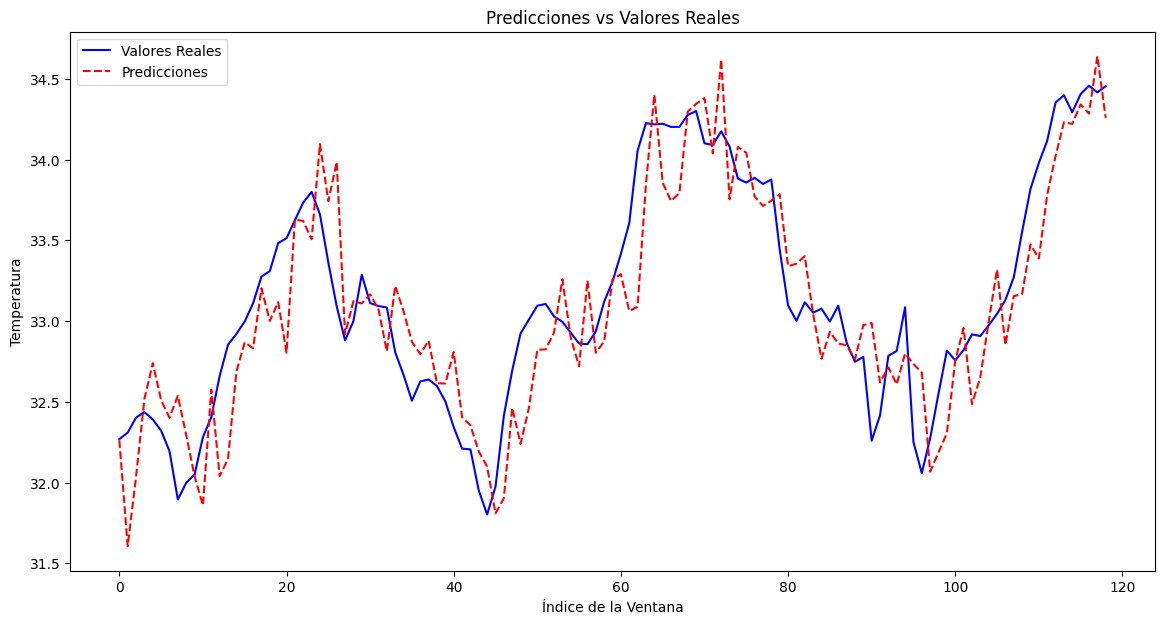

In [ ]:
import matplotlib.pyplot as plt

# Crear una figura y un conjunto de ejes
plt.figure(figsize=(14, 7))

# Graficar los valores reales
plt.plot(range(len(y_test)), y_test, label='Valores Reales', color='blue')

# Graficar las predicciones
plt.plot(range(len(predictions)), predictions, label='Predicciones', color='red', linestyle='--')

# Añadir etiquetas y título
plt.xlabel('Índice de la Ventana')
plt.ylabel('Temperatura')
plt.title('Predicciones vs Valores Reales')
plt.legend()

# Mostrar la gráfica
plt.show()


In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn.metrics import mean_squared_error

# Definir el tamaño de la ventana
window_size = 5

# Crear las ventanas deslizantes para el conjunto de datos
def create_dataset(df, window_size):
    X, y = [], []
    values = df['Humidity'].values
    for i in range(len(values) - window_size):
        X.append(values[i:i + window_size])
        y.append(values[i + window_size])
    return np.array(X), np.array(y)

# Preparar las entradas (X) y las salidas (y)
X, y = create_dataset(df, window_size)

# Definir el tamaño del conjunto de entrenamiento
train_size = int(len(X) * 0.5)

# Crear y compilar el modelo
def create_model(window_size):
    model = Sequential()
    model.add(Input(shape=(window_size,)))  # Definir la forma de entrada
    model.add(Dense(20, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# Validación Walk-Forward
predictions = []
model = create_model(window_size)

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# Entrenar el modelo con el conjunto inicial
model.fit(X_train, y_train, epochs=50, batch_size=1, verbose=2)

# Walk-forward
for i in range(len(X_test)):
    # Predecir el siguiente valor
    prediction = model.predict(X_test[i].reshape(1, -1), verbose=0)
    predictions.append(prediction[0, 0])

    # Agregar el nuevo punto a los datos de entrenamiento (ventana)
    X_train = np.vstack([X_train, X_test[i]])
    y_train = np.append(y_train, y_test[i])

    # Reentrenar el modelo con la nueva ventana
    model.fit(X_train, y_train, epochs=1, batch_size=1, verbose=0)

# Evaluar las predicciones
mse = mean_squared_error(y_test, predictions)
rsme = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rsme)

Epoch 1/50
119/119 - 2s - 18ms/step - loss: 885.9645
Epoch 2/50
119/119 - 1s - 8ms/step - loss: 107.1017
Epoch 3/50
119/119 - 1s - 5ms/step - loss: 11.0249
Epoch 4/50
119/119 - 0s - 4ms/step - loss: 8.4225
Epoch 5/50
119/119 - 0s - 3ms/step - loss: 8.1690
Epoch 6/50
119/119 - 0s - 3ms/step - loss: 7.4869
Epoch 7/50
119/119 - 1s - 5ms/step - loss: 7.1109
Epoch 8/50
119/119 - 0s - 2ms/step - loss: 6.7046
Epoch 9/50
119/119 - 1s - 5ms/step - loss: 6.3599
Epoch 10/50
119/119 - 0s - 2ms/step - loss: 5.9244
Epoch 11/50
119/119 - 0s - 1ms/step - loss: 5.5483
Epoch 12/50
119/119 - 0s - 1ms/step - loss: 5.1688
Epoch 13/50
119/119 - 0s - 3ms/step - loss: 4.9582
Epoch 14/50
119/119 - 0s - 1ms/step - loss: 4.4653
Epoch 15/50
119/119 - 0s - 1ms/step - loss: 4.2895
Epoch 16/50
119/119 - 0s - 1ms/step - loss: 4.0294
Epoch 17/50
119/119 - 0s - 3ms/step - loss: 3.7793
Epoch 18/50
119/119 - 0s - 3ms/step - loss: 3.4511
Epoch 19/50
119/119 - 0s - 2ms/step - loss: 3.3066
Epoch 20/50
119/119 - 0s - 1ms/ste

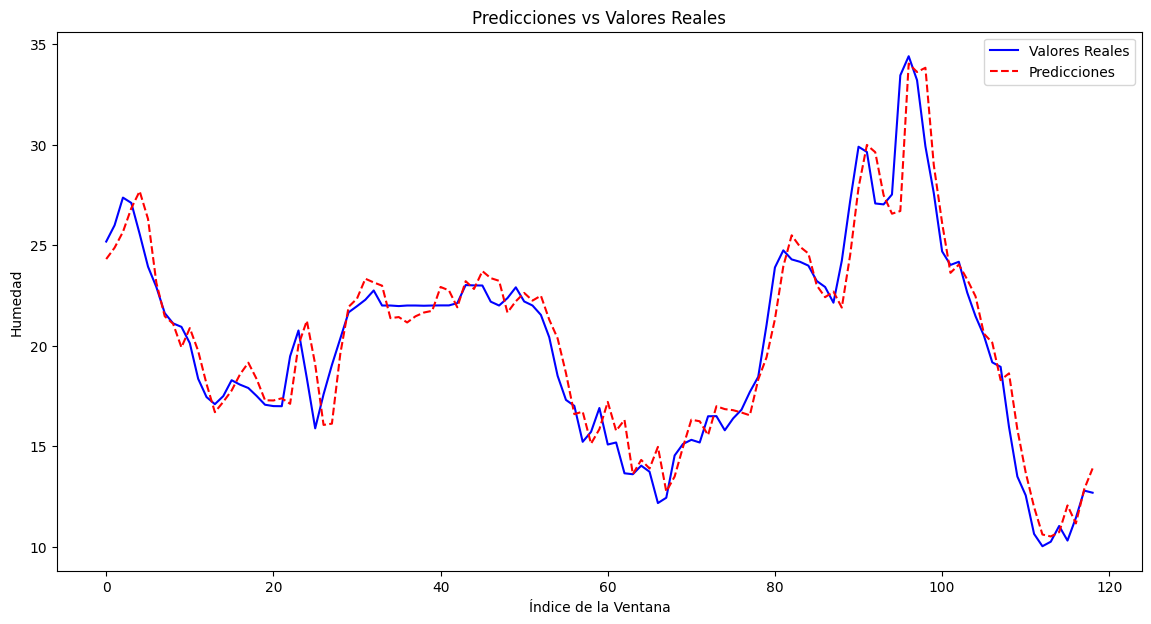

In [ ]:
import matplotlib.pyplot as plt

# Crear una figura y un conjunto de ejes
plt.figure(figsize=(14, 7))

# Graficar los valores reales
plt.plot(range(len(y_test)), y_test, label='Valores Reales', color='blue')

# Graficar las predicciones
plt.plot(range(len(predictions)), predictions, label='Predicciones', color='red', linestyle='--')

# Añadir etiquetas y título
plt.xlabel('Índice de la Ventana')
plt.ylabel('Humedad')
plt.title('Predicciones vs Valores Reales')
plt.legend()

# Mostrar la gráfica
plt.show()
